## Introducción

Este proyecto analiza la relación entre movilidad urbana y productividad económica en ciudades latinoamericanas durante 2024. Para ello, se integran datos de tráfico y variables económicas con el fin de comparar ciudades, identificar patrones de congestión y reconocer posibles prioridades para inversión en transporte.

El análisis utiliza indicadores como retraso por congestión, índice de tráfico, PIB per cápita, desempleo, población y contaminación PM2.5. Estos datos permiten construir una lectura inicial sobre las condiciones urbanas y económicas de las ciudades analizadas.

El objetivo no es afirmar una relación causal directa entre congestión y productividad, sino generar evidencia útil para el monitoreo urbano, la comparación entre ciudades y la toma de decisiones en planificación territorial.

---
## Enfoque del análisis

El proyecto se desarrolla desde un enfoque de análisis de datos aplicado a problemas urbanos. A través de la limpieza, integración y visualización de datos, se busca transformar información dispersa en indicadores útiles para interpretar condiciones de movilidad, economía y bienestar urbano.

Desde esta perspectiva, el análisis combina tres componentes: exploración de datos, investigación aplicada y monitoreo de indicadores. Esto permite identificar ciudades con mayores presiones de movilidad y orientar preguntas para futuros análisis o decisiones de inversión.

## 🧩 Paso 1: Cargar y explorar

### 1.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.


In [ ]:
# importar librerías
import pandas as pd
import numpy as num
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/content/tomtom_traffic.csv')
eco = pd.read_csv('/content/oecd_city_economy.csv')

In [ ]:
# Información traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
# Mostrar tabla traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


**Comentario**
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` cambiar formato a `DateTime`.
- JamsCount cambiar a formato `Integer`.
- No hay datos vacíos.


In [ ]:
# Cantidad de valores únicos
columnas_categoricas_traffic = ['Country', 'City']

for col in columnas_categoricas_traffic:
    print(f"\nCantidad de valores únicos en {col}:")
    print(traffic[col].nunique())


Cantidad de valores únicos en Country:
55

Cantidad de valores únicos en City:
384


In [ ]:
# Valores únicos traffic

for col in columnas_categoricas_traffic:
    print(f"\nValores únicos en {col}:")
    print(traffic[col].unique())



Valores únicos en Country:
['ARE' 'ARG' 'AUS' 'AUT' 'BEL' 'BGR' 'BRA' 'CAN' 'CHE' 'CHL' 'COL' 'CZE'
 'DEU' 'DNK' 'EGY' 'ESP' 'EST' 'FIN' 'FRA' 'GBR' 'GRC' 'HKG' 'HUN' 'IDN'
 'IND' 'IRL' 'ISL' 'ITA' 'JPN' 'KWT' 'LTU' 'LUX' 'LVA' 'MEX' 'MYS' 'NLD'
 'NOR' 'NZL' 'PER' 'PHL' 'POL' 'PRT' 'QAT' 'ROU' 'SAU' 'SGP' 'SVK' 'SVN'
 'SWE' 'THA' 'TUR' 'TWN' 'URY' 'USA' 'ZAF']

Valores únicos en City:
['abu-dhabi' 'al-ain' 'dubai' 'fujairah' 'ras-al-khaimah' 'sharja'
 'buenos-aires' 'adelaide' 'brisbane' 'canberra' 'gold-coast' 'hobart'
 'melbourne' 'newcastle' 'perth' 'sydney' 'wollongong' 'graz' 'innsbruck'
 'linz' 'salzburg' 'vienna' 'antwerp' 'bruges' 'brussels' 'charleroi'
 'ghent' 'kortrijk' 'leuven' 'liege' 'mons' 'namur' 'sofia'
 'belo-horizonte' 'brasilia' 'curitiba' 'fortaleza' 'porto-alegre'
 'recife' 'rio-de-janeiro' 'salvador' 'sao-paulo' 'calgary' 'edmonton'
 'halifax' 'hamilton' 'kitchener-waterloo' 'london' 'montreal' 'ottawa'
 'quebec' 'toronto' 'vancouver' 'winnipeg' 'basel' 'bern' '

In [ ]:
# Información eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


In [ ]:
# Mostrar tabla eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Comentario**
- Columnas `City GDP/capita`, `Unemployment %`,`PM2.5 (μg/m³)`, `Population (M)` cambiar formato a `Integer`
- Estandarizar decimal columnas númericas
- No hay datos vacíos.


  

In [ ]:
# Cantidad valores únicos eco
columnas_categoricas_eco = ['Country', 'City']

for col in columnas_categoricas_eco:
    print(f"\nValores únicos en {col}:")
    print(eco[col].nunique())


Valores únicos en Country:
7

Valores únicos en City:
15


In [ ]:
# Valores únicos eco
for col in columnas_categoricas_eco:
    print(f"\nValores únicos en {col}:")
    print(eco[col].unique())


Valores únicos en Country:
['Argentina' 'Brazil' 'Chile' 'Colombia' 'Mexico' 'Peru' 'Uruguay']

Valores únicos en City:
['buenos-aires' 'sao-paulo' 'rio-de-janeiro' 'brasilia' 'salvador'
 'fortaleza' 'belo-horizonte' 'curitiba' 'recife' 'porto-alegre'
 'santiago' 'bogota' 'mexico-city' 'lima' 'montevideo']



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos
### 2.1 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.



In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns = [
    'country',
    'city',
    'update_time_utc',
    'jams_delay',
    'traffic_index_live',
    'jams_length_kms',
    'jams_count',
    'traffic_index_week_ago',
    'update_time_utc_week_ago',
    'travel_time_live_10km_mins',
    'travel_time_historic_10km_mins',
    'mins_delay'
]
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_10km_mins', 'travel_time_historic_10km_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco.columns = [
    'year',
    'city',
    'country',
    'city_gdp_per_capita',
    'unemployment_pct',
    'pm25_ug_m3',
    'population_m'
]

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_per_capita', 'unemployment_pct',
       'pm25_ug_m3', 'population_m'],
      dtype='object')


### 2.2 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.


In [ ]:
# Función cambio de formato a fecha

def cambio_formato_fecha (df,columna):
  df[columna]= pd.to_datetime(df[columna],errors='coerce',utc=True)
  return df[columna]

In [ ]:
traffic['update_time_utc'] = cambio_formato_fecha(traffic,'update_time_utc')
traffic['update_time_utc_week_ago'] = cambio_formato_fecha(traffic,'update_time_utc_week_ago')
traffic[['update_time_utc','update_time_utc_week_ago']].dtypes

,0
update_time_utc,"datetime64[ns, UTC]"
update_time_utc_week_ago,"datetime64[ns, UTC]"


In [ ]:
# Columna númerica a formato int
traffic['jams_count'] = traffic['jams_count'].astype('Int64')
traffic['jams_count'].dtypes

Int64Dtype()

In [ ]:
# Limpiar separadores y convierte columnas numéricas en eco

# Columna eco['city_gdp_capita']
eco['city_gdp_per_capita'] = eco['city_gdp_per_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Columna eco['unemployment_pct']
eco['unemployment_pct'] =eco['unemployment_pct']. astype(str).str.replace('%', '').str.replace(',', '.').astype(float)

# Columna eco['population_m']
eco['population_m']=eco['population_m'].astype(str).str.replace(',','.').astype(float)

# Columna eco['pm25_ug_m3']
eco['pm25_ug_m3'] = eco['pm25_ug_m3'].astype(str).str.replace(',', '.').astype(float)

# Calcular la población total en unidades absolutas
eco['population_total'] =eco['population_m']*1_000_000

# verificar el cambio
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   city_gdp_per_capita  30 non-null     float64
 4   unemployment_pct     30 non-null     float64
 5   pm25_ug_m3           30 non-null     float64
 6   population_m         30 non-null     float64
 7   population_total     30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


In [ ]:
# Mostrar tabla
eco.head(3)

,year,city,country,city_gdp_per_capita,unemployment_pct,pm25_ug_m3,population_m,population_total
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


### 2.3 Estandarizar texto
🎯Objetivo: Asegurar que los nombres de los países estén escrito de la misma manera en ambas tablas.

In [ ]:
country_map = {
    'Argentina': 'ARG',
    'Brazil': 'BRA',
    'Chile': 'CHL',
    'Colombia': 'COL',
    'Mexico': 'MEX',
    'Peru': 'PER',
    'Uruguay': 'URY'
}

eco['country'] = eco['country'].replace(country_map)


---

## 🧩Paso 3: Extraer año y filtrar

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.


In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_10km_mins,travel_time_historic_10km_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtrar los registros del año 2024 en traffic

# traffic_2024
traffic_2024 = traffic[traffic['year']==2024].copy(deep=True)

# Revisar dataframes nuevos
display(traffic_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_10km_mins,travel_time_historic_10km_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


In [ ]:
# Filas, columnas traffic_2024
traffic_2024.shape

(886779, 13)

In [ ]:
# Filtrar los registros del año 2024 en eco

# eco_2024
eco_2024 = eco[eco['year']==2024].copy(deep=True)

# Revisar dataframes nuevos
display(eco_2024.head())


,year,city,country,city_gdp_per_capita,unemployment_pct,pm25_ug_m3,population_m,population_total
15,2024,buenos-aires,ARG,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,BRA,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,BRA,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,BRA,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,BRA,8899.0,12.4,15.2,3.9,3900000.0


In [ ]:
# filas, columnas eco_2024
eco_2024.shape

(15, 8)


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.


In [ ]:
traffic_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 886779 entries, 302 to 1004463
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype              
---  ------                          --------------   -----              
 0   country                         886779 non-null  object             
 1   city                            886779 non-null  object             
 2   update_time_utc                 886779 non-null  datetime64[ns, UTC]
 3   jams_delay                      886779 non-null  float64            
 4   traffic_index_live              886779 non-null  float64            
 5   jams_length_kms                 886779 non-null  float64            
 6   jams_count                      886779 non-null  Int64              
 7   traffic_index_week_ago          886779 non-null  float64            
 8   update_time_utc_week_ago        886779 non-null  datetime64[ns, UTC]
 9   travel_time_live_10km_mins      886779 non-null  float64            
 10

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city','country','year']).agg({'jams_delay':'mean',
                                                                              'traffic_index_live':'mean',
                                                                              'jams_length_kms': 'mean',
                                                                              'jams_count': 'mean',
                                                                              'traffic_index_week_ago': 'mean',
                                                                              'travel_time_live_10km_mins': 'mean',
                                                                              'travel_time_historic_10km_mins': 'mean',
                                                                              'mins_delay': 'mean'
                                                                             }).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,travel_time_live_10km_mins,travel_time_historic_10km_mins,mins_delay
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,15.821025,16.267977,15.493804,0.774172
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,21.874836,13.397861,12.604894,0.792968
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,17.445227,15.219292,14.724016,0.495276
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,14.295209,9.829092,9.689328,0.139764
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.75462,22.508810,15.879694,14.749945,1.129749


In [ ]:
# Promedio anuales de tráfico por ciudad: mayor a menor

promedio_trafico_mayor_menor=traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)
promedio_trafico_mayor_menor.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,travel_time_live_10km_mins,travel_time_historic_10km_mins,mins_delay
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,36.443813,21.809092,19.953550,1.855542
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.80942,37.441779,22.443778,21.745626,0.698152
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,29.337407,18.505043,17.108691,1.396351
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,30.827376,17.714139,16.388979,1.325160
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,68.628341,27.134629,24.664734,2.469894


**Comentario**  
La ciudad con el mayor tiempo promedio de tráfico es `México`, siendo la única ciudad Latinoamericana. Seguida de Tokyo (Asia), New York (Norte América), Londres (Europa) y Manila (Asia).


---

## 🧩Paso 5: Unir movilidad y economía

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.



In [ ]:
# Seleccionar columnas centrales para el análisi
traffic_2024_small = traffic_2024[[
    'city',
    'country',
    'year',
    'jams_delay',
    'jams_count',
    'jams_length_kms',
    'mins_delay',
    'traffic_index_live',
    'travel_time_live_10km_mins'
]].copy(deep=True)

eco_2024_small = eco_2024[[
    'city',
    'country',
    'year',
    'city_gdp_per_capita',
    'unemployment_pct',
    'population_m',
    'pm25_ug_m3'
]].copy(deep=True)

# Unir datasets
traffic_eco_2024 = pd.merge(traffic_2024_small,eco_2024_small,on=['country','city','year'],how='inner')

# Mostrar las primeras 5 filas
traffic_eco_2024.head(5)

,city,country,year,jams_delay,jams_count,jams_length_kms,mins_delay,traffic_index_live,travel_time_live_10km_mins,city_gdp_per_capita,unemployment_pct,population_m,pm25_ug_m3
0,buenos-aires,ARG,2024,138.3,43,44.6,-0.248936,11.0,16.569802,18117.0,7.2,15.4,14.5
1,buenos-aires,ARG,2024,66.8,27,26.6,-0.799344,9.0,16.142125,18117.0,7.2,15.4,14.5
2,buenos-aires,ARG,2024,33.5,14,8.6,-1.688390,5.0,15.614398,18117.0,7.2,15.4,14.5
3,buenos-aires,ARG,2024,25.7,9,2.6,-1.677855,3.0,15.369625,18117.0,7.2,15.4,14.5
4,buenos-aires,ARG,2024,34.6,12,3.8,-1.412564,2.0,15.215201,18117.0,7.2,15.4,14.5


In [ ]:
# Vacíos traffic_eco_2024
traffic_eco_2024.isna().sum()

,0
city,0
country,0
year,0
jams_delay,0
jams_count,0
jams_length_kms,0
mins_delay,0
traffic_index_live,0
travel_time_live_10km_mins,0
city_gdp_per_capita,0



---

## 🧩Paso 6: Visualización y análisis de relaciones

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


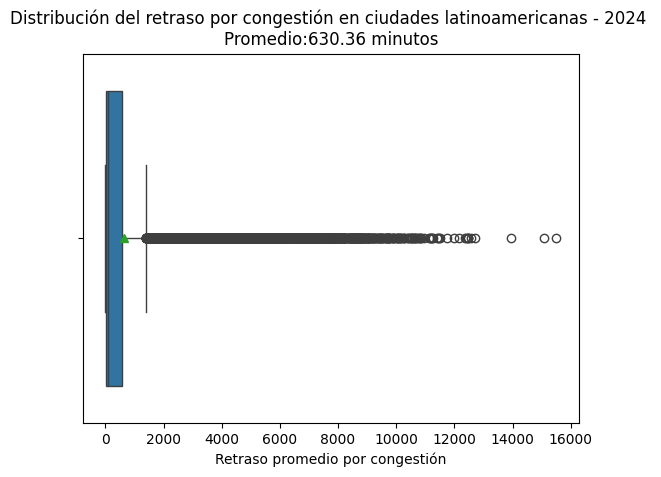

In [ ]:
# Boxplot para observar el comportamiento de los minutos de congestion JamsDelay

# Gráfico

sns.boxplot(data=traffic_eco_2024,x='jams_delay',showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = traffic_eco_2024['jams_delay'].mean()

plt.title(f'Distribución del retraso por congestión en ciudades latinoamericanas - 2024 \nPromedio:{mean_value:.2f} minutos')
plt.xlabel('Retraso promedio por congestión')
plt.show()


**Comentario**  
El gráfico aparece comprimido por la presencia de varios valores atípicos. La mayoría de las ciudades se concentra en un rango cercano entre 0 y 2.000 de retraso promedio por congestión, mientras que algunos casos presentan valores mucho más altos. Estos valores extremos son relevantes porque pueden indicar ciudades con mayores problemas de movilidad urbana y, por tanto, posibles prioridades para inversión en infraestructura de transporte.

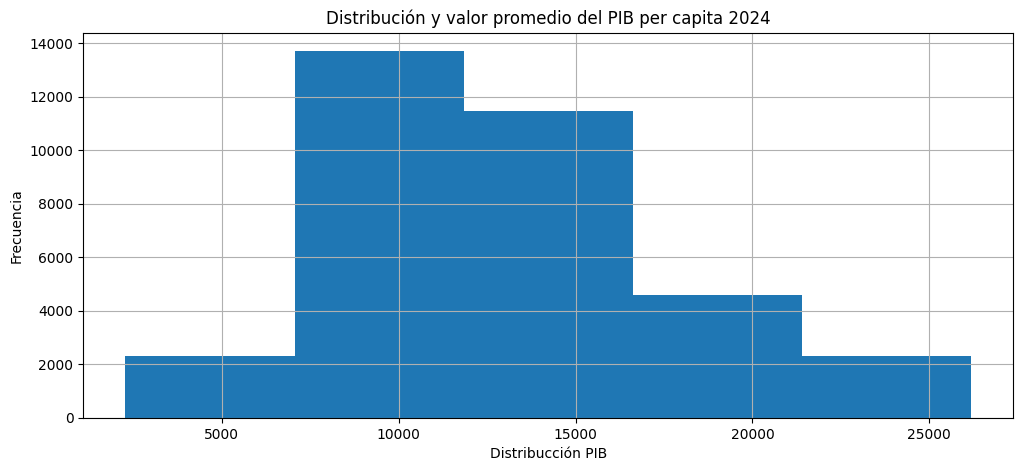

In [ ]:
# Histograma para ver la distribución de la economía (city_gdp_capita)

traffic_eco_2024['city_gdp_per_capita'].hist(bins=5,figsize=(12,5))

plt.title('Distribución y valor promedio del PIB per capita 2024')
plt.xlabel('Distribucción PIB')
plt.ylabel('Frecuencia')
plt.show()

**Comentario**  
El histograma muestra la distribución del PIB per cápita por ciudad en 2024. La mayoría de los datos se concentra aproximadamente entre 6.000 y 16.000, lo que sugiere que varias ciudades presentan niveles económicos intermedios. La distribución no es completamente simétrica, ya que existen valores inferiores y superiores al rango principal. Estos contrastes son relevantes porque permiten comparar la productividad económica con los niveles de congestión urbana y definir posibles prioridades de inversión en transporte.


In [ ]:
# Correlación Spearman entre jams_delay y city_gdp_capita por ciudad
correlacion = traffic_eco_2024['jams_delay'].corr(traffic_eco_2024['city_gdp_per_capita'], method='spearman')
print(f'Correlación entre retraso por congestión y PIB per cápita: {correlacion:.2f}')

Correlación entre retraso por congestión y PIB per cápita: 0.13


**Comentario**  
La correlación de Spearman entre el retraso por congestión y el PIB per cápita fue de 0.13, lo que indica una relación positiva muy débil. En las ciudades analizadas no se observa una asociación fuerte entre congestión vial y productividad económica, por lo que no puede afirmarse una relación causal.


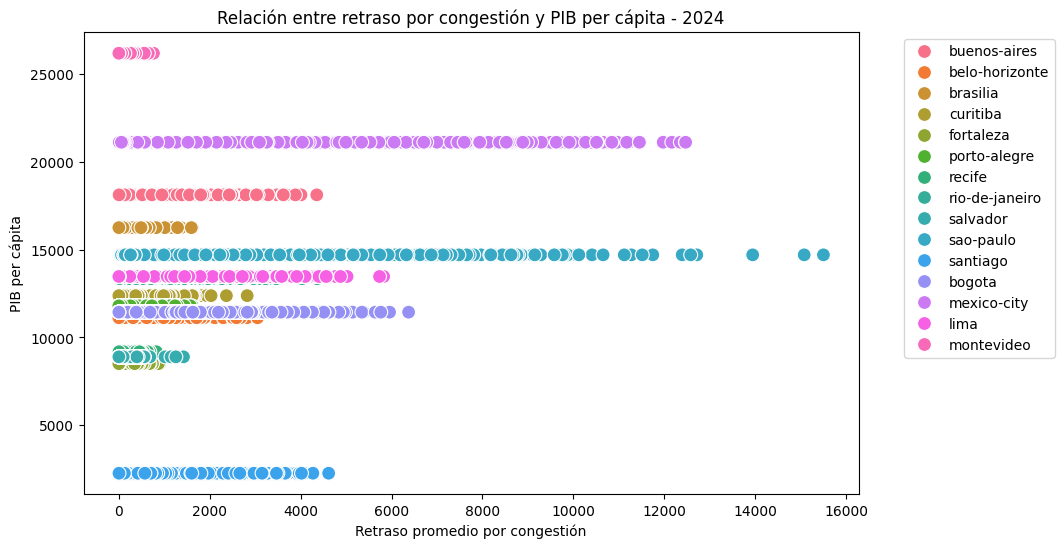

In [ ]:
# Gráfico dispersión
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=traffic_eco_2024,
    x='jams_delay',
    y='city_gdp_per_capita',
    hue='city',
    s=100
)

plt.title('Relación entre retraso por congestión y PIB per cápita - 2024')
plt.xlabel('Retraso promedio por congestión')
plt.ylabel('PIB per cápita')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Comentario**  
El gráfico muestra una relación positiva muy débil entre el retraso por congestión y el PIB per cápita. Aunque la congestión no explica por sí sola la productividad económica, se observan ciudades como São Paulo, Ciudad de México, Lima y Bogotá con mayores niveles de retraso. Estos casos son relevantes porque la congestión puede afectar la calidad de vida, el acceso al empleo y la organización cotidiana, por lo que deberían revisarse como posibles prioridades de inversión en transporte.

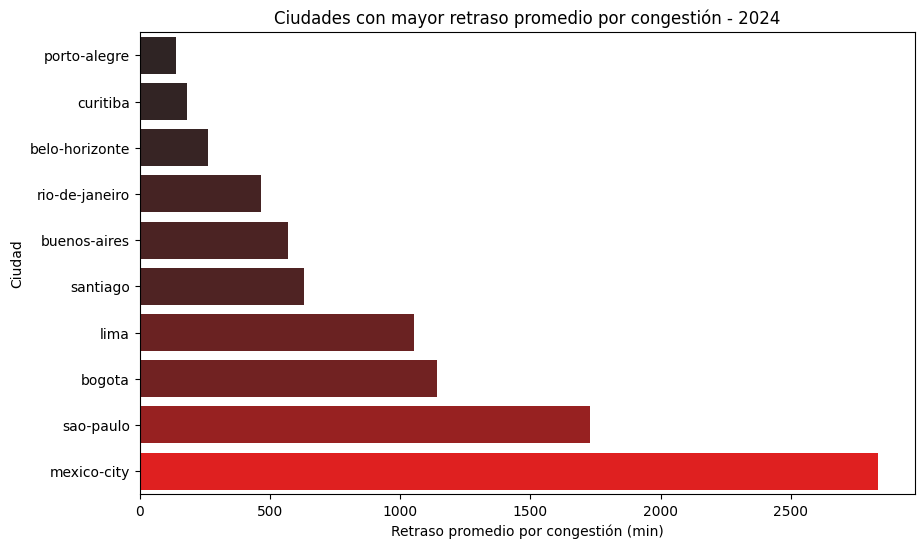

In [ ]:
# Gráfico de barras ciudad con más retraso por congetsión

# Agrupar datos por ciudad
top_ciudades = (
    traffic_eco_2024
    .groupby('city', as_index=False)['jams_delay']
    .mean()
    .sort_values('jams_delay', ascending=False)
    .head(10)
)

# Crear gráfico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_ciudades,
    x='jams_delay',
    y='city',
    hue='jams_delay',
    palette='dark:red',
    legend=False
)

plt.title('Ciudades con mayor retraso promedio por congestión - 2024')
plt.xlabel('Retraso promedio por congestión (min)')
plt.ylabel('Ciudad')
plt.gca().invert_yaxis()
plt.show()


**Comentario**  
El gráfico muestra las ciudades con mayor retraso promedio por congestión en 2024. Ciudad de México presenta el valor más alto, seguida por São Paulo, Bogotá y Lima, lo que evidencia una mayor presión sobre sus sistemas de movilidad urbana.

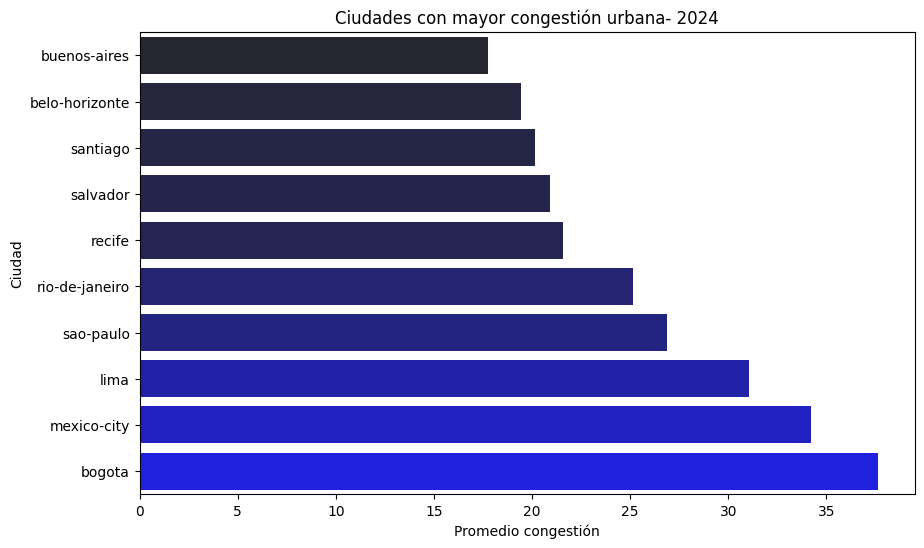

In [ ]:
# Gráfico nivel de intensidad del tráfico

# Agrupar datos por ciudad

top_ciudades_traffic = (
    traffic_eco_2024
    .groupby('city', as_index=False)['traffic_index_live']
    .mean()
    .sort_values('traffic_index_live', ascending=False)
    .head(10)
)

# Crear gráfico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_ciudades_traffic,
    x='traffic_index_live',
    y='city',
    hue='traffic_index_live',
    palette='dark:blue',
    legend=False
)

plt.title('Ciudades con mayor congestión urbana- 2024')
plt.xlabel('Promedio congestión')
plt.ylabel('Ciudad')
plt.gca().invert_yaxis()
plt.show()



**Comentario**  
El gráfico muestra las ciudades con mayor congestión urbana en 2024. Bogotá presenta el promedio más alto, seguida por Ciudad de México, Lima, São Paulo y Río de Janeiro, lo que evidencia una mayor presión sobre sus sistemas de transporte.

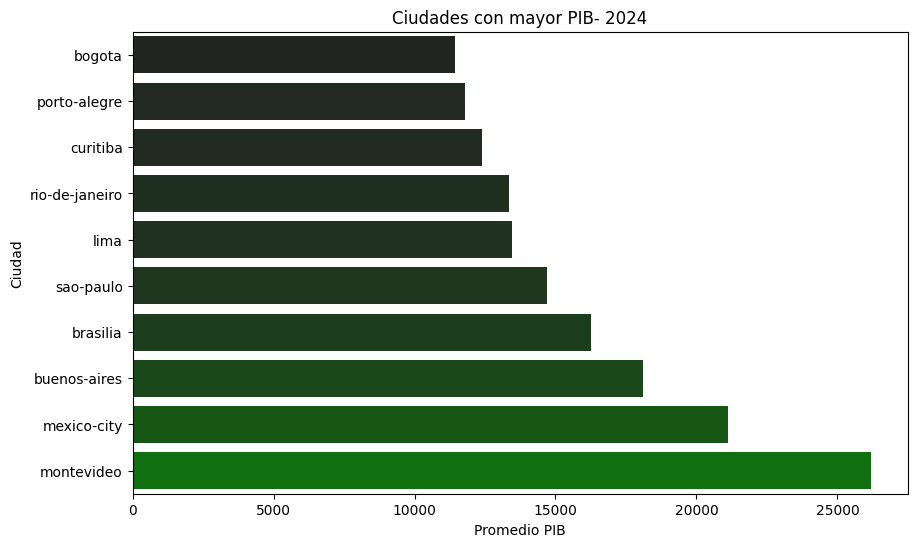

In [ ]:
# Ciudad con mayor PIB

# Agrupar datos por ciudad

top_ciudades_pib = (
    traffic_eco_2024
    .groupby('city', as_index=False)['city_gdp_per_capita']
    .mean()
    .sort_values('city_gdp_per_capita', ascending=False)
    .head(10)
)

# Crear gráfico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_ciudades_pib,
    x='city_gdp_per_capita',
    y='city',
    hue='city_gdp_per_capita',
    palette='dark:green',
    legend=False
)

plt.title('Ciudades con mayor PIB- 2024')
plt.xlabel('Promedio PIB')
plt.ylabel('Ciudad')
plt.gca().invert_yaxis()
plt.show()


**Comentario**  
El gráfico muestra las ciudades con mayor PIB per cápita en 2024. Montevideo presenta el valor más alto, seguida por Ciudad de México, Buenos Aires, Brasilia y São Paulo. Esto indica que estas ciudades tienen un mayor nivel de productividad económica dentro del grupo analizado.

Estos resultados permiten observar diferencias importantes entre ciudades latinoamericanas. Un PIB per cápita más alto puede reflejar mayor capacidad económica, mejores oportunidades laborales y mayor potencial para financiar proyectos urbanos.

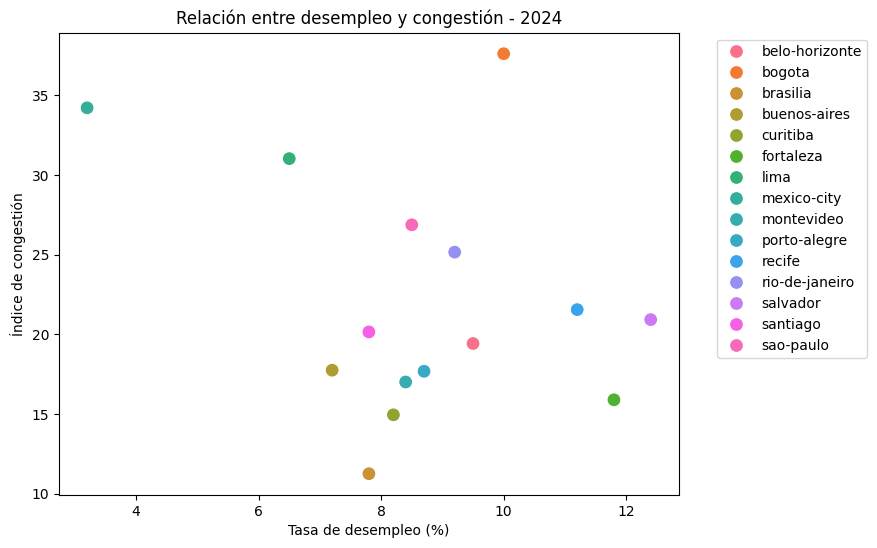

In [ ]:
# Ciudad con más desempleo y mala movilidad
# Agrupar por ciudad
trafico_desempleo = (
    traffic_eco_2024
    .groupby(['city', 'country'], as_index=False)
    .agg({
        'unemployment_pct': 'mean',
        'traffic_index_live': 'mean'
    })
)
# Grafico
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=trafico_desempleo,
    x='unemployment_pct',
    y='traffic_index_live',
    hue='city',
    s=100
)

plt.title('Relación entre desempleo y congestión - 2024')
plt.xlabel('Tasa de desempleo (%)')
plt.ylabel('Índice de congestión')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Comentario**  
El gráfico muestra la relación entre la tasa de desempleo y el índice de congestión urbana en 2024. Se observa que no todas las ciudades con mayor desempleo presentan los niveles más altos de congestión, por lo que la relación entre ambas variables no parece ser completamente directa.

Sin embargo, algunas ciudades combinan niveles altos de desempleo con congestión importante, lo que puede reflejar mayores dificultades para la población.

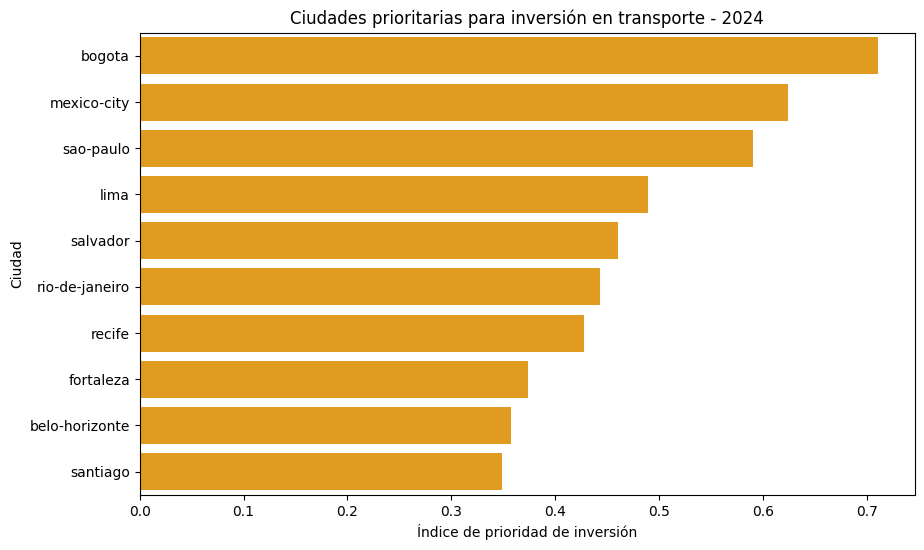

In [ ]:
# Gráfica prioridad ciudad para inversión

# Agrupar por ciudad
prioridad = (
    traffic_eco_2024
    .groupby(['city', 'country'], as_index=False)
    .agg({
        'traffic_index_live': 'mean',
        'jams_delay': 'mean',
        'unemployment_pct': 'mean'
    })
)

# Normalizar columnas de 0 a 1
for col in ['traffic_index_live', 'jams_delay', 'unemployment_pct']:
    prioridad[col + '_norm'] = (
        prioridad[col] - prioridad[col].min()
    ) / (
        prioridad[col].max() - prioridad[col].min()
    )

# Índice de prioridad
prioridad['indice_prioridad'] = (
    prioridad['traffic_index_live_norm'] +
    prioridad['jams_delay_norm'] +
    prioridad['unemployment_pct_norm']
) / 3

# Top 10
top_prioridad = (
    prioridad
    .sort_values('indice_prioridad', ascending=False)
    .head(10)
)

# Gráfica
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_prioridad,
    x='indice_prioridad',
    y='city',
    color='orange'
)

plt.title('Ciudades prioritarias para inversión en transporte - 2024')
plt.xlabel('Índice de prioridad de inversión')
plt.ylabel('Ciudad')
plt.show()

**Comentario**  
El gráfico muestra las ciudades prioritarias para inversión en transporte en 2024, según el índice construido a partir de variables de movilidad y contexto económico. Bogotá aparece como la ciudad con mayor prioridad, seguida por Ciudad de México, São Paulo y Lima.

El índice de prioridad permite ordenar las ciudades según tres variables: índice de congestión, retraso por congestión y desempleo. Este indicador ayuda a identificar ciudades donde las condiciones de movilidad y contexto económico pueden requerir mayor atención.

Este índice debe interpretarse como una herramienta inicial de monitoreo y priorización, no como una conclusión definitiva. Para tomar decisiones de inversión sería necesario complementar el análisis con información sobre infraestructura existente, cobertura del transporte público, tiempos de viaje y acceso a centros de empleo.

In [ ]:
# Exporta el dataset final como CSV
traffic_eco_2024.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Conclusiones y recomendaciones

## Conclusiones

* El proyecto permitió integrar datos de movilidad urbana y variables económicas para analizar el comportamiento de **15 ciudades latinoamericanas en 2024**, ubicadas en **7 países**: Brasil, Colombia, Argentina, Perú, México, Chile y Uruguay.

* La limpieza y preparación de datos fue una etapa clave del análisis. Se estandarizaron nombres de columnas, formatos de fecha, variables numéricas y nombres de países, lo que permitió unir correctamente la información de tráfico y economía mediante una unión `INNER`.

* El análisis mostró que **Ciudad de México** presentó el mayor retraso promedio por congestión dentro del grupo analizado. También se destacaron **São Paulo, Bogotá y Lima** como ciudades con altos niveles de retraso vial.

* Al revisar el índice de congestión urbana, **Bogotá** apareció como la ciudad con mayor nivel promedio de congestión, seguida por **Ciudad de México, Lima, São Paulo y Río de Janeiro**. Esto evidencia una mayor presión sobre los sistemas de movilidad en estas ciudades.

* La correlación de Spearman entre retraso por congestión y PIB per cápita fue de **0.13**, lo que indica una relación positiva muy débil. Por lo tanto, no se puede afirmar que exista una relación directa fuerte entre congestión y productividad económica con los datos analizados.

* **Montevideo** presentó el mayor PIB per cápita dentro del grupo, seguida por **Ciudad de México, Buenos Aires, Brasilia y São Paulo**. Esto muestra diferencias económicas importantes entre las ciudades latinoamericanas analizadas.

* El índice de prioridad construido a partir de variables de movilidad y contexto económico ubicó a **Bogotá** como la ciudad con mayor prioridad para inversión en transporte, seguida por **Ciudad de México, São Paulo y Lima**.

* En general, el proyecto muestra que los datos de movilidad y economía pueden utilizarse como insumo para monitorear condiciones urbanas, identificar ciudades con mayores presiones y orientar decisiones de inversión pública o planificación territorial.

## Recomendaciones

* Priorizar el análisis de **Bogotá, Ciudad de México, São Paulo y Lima**, ya que concentran altos niveles de congestión, retrasos viales o presión sobre sus sistemas de transporte.

* Usar el índice de prioridad como una herramienta inicial de monitoreo, no como una conclusión definitiva. Este índice permite ordenar ciudades según variables clave, pero debe complementarse con información adicional antes de tomar decisiones de inversión.

* Profundizar el análisis de Bogotá, debido a que aparece como la ciudad con mayor prioridad según el índice construido. Sería importante revisar variables adicionales como calidad del transporte público, tiempos de viaje por zona, acceso al empleo, infraestructura disponible y distribución territorial de la población.

* No interpretar la congestión como causa directa de menor productividad económica. La correlación encontrada entre retraso por congestión y PIB per cápita fue débil, por lo que se recomienda complementar el análisis con más variables y métodos estadísticos.

* Utilizar visualizaciones y dashboards para comunicar los resultados de forma clara a equipos técnicos, instituciones públicas u organizaciones interesadas en movilidad urbana, productividad y bienestar social.
